# StockDB — Screener d'actions et analyse sectorielle

**Data Analyst — Finance, Business Intelligence et Aide à la décision**

Ce notebook interroge la base `stockdb.sqlite` (schéma : `entreprises`, `secteurs`, `cours`, `indicateurs_financiers`) pour répondre à des questions concrètes qu'un investisseur particulier se pose :

1. Quelles actions ont le plus/moins performé récemment, secteur par secteur ?
2. Quelles actions sont aujourd'hui sous-évaluées avec un dividende attractif ?
3. Comment suivre la variation quotidienne d'une action précise ?
4. Quels secteurs ont été les plus dynamiques sur les 30 derniers jours ?

> Données simulées à des fins de démonstration — cohérentes avec le portefeuille étudié dans le projet MarketPulse.


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("stockdb.sqlite")


## 1. Top performers du mois, par secteur

Utilise les fonctions de fenêtrage `FIRST_VALUE`, `ROW_NUMBER` et `RANK` pour classer chaque action au sein de son secteur sur les 30 derniers jours, sans sous-requête répétée.

In [2]:
Q1 = """
WITH rendements AS (
    SELECT
        c.ticker,
        e.secteur,
        c.cours_cloture,
        FIRST_VALUE(c.cours_cloture) OVER (
            PARTITION BY c.ticker ORDER BY c.date_cours
        ) AS cours_debut_periode,
        ROW_NUMBER() OVER (
            PARTITION BY c.ticker ORDER BY c.date_cours DESC
        ) AS rang_recent
    FROM cours c
    JOIN entreprises e ON e.ticker = c.ticker
    WHERE c.date_cours >= DATE((SELECT MAX(date_cours) FROM cours), '-30 days')
)
SELECT
    ticker, secteur,
    ROUND((cours_cloture - cours_debut_periode) / cours_debut_periode * 100, 2) AS rendement_pct,
    RANK() OVER (PARTITION BY secteur ORDER BY (cours_cloture - cours_debut_periode)/cours_debut_periode DESC) AS rang_secteur
FROM rendements
WHERE rang_recent = 1
ORDER BY secteur, rang_secteur;
"""

df_q1 = pd.read_sql_query(Q1, conn)
df_q1

ticker,secteur,rendement_pct,rang_secteur
MC,Consommation,7.52,1
KO,Consommation,2.76,2
XOM,Energie,14.88,1
TTE,Energie,4.33,2
JPM,Finance,5.30,1
BNP,Finance,3.49,2
JNJ,Sante,7.25,1
SAN,Sante,-6.80,2
MSFT,Technologie,5.95,1
AAPL,Technologie,2.05,2


**Lecture :** LVMH et Exxon Mobil sont les meilleures performances de leur secteur respectif sur la période. Sanofi est la seule action en territoire négatif (-6.8%) — un signal à surveiller plutôt qu'une alerte en soi, à confirmer avec le ratio de Sharpe (cf. projet MarketPulse).

## 2. Screener — actions sous-évaluées avec un dividende attractif

Filtre simple mais efficace : P/E inférieur à 15 et rendement du dividende supérieur à 3 %, sur le dernier instantané de données fondamentales disponible.

In [3]:
Q2 = """
SELECT e.ticker, e.nom, e.secteur, i.pe_ratio, i.dividende_rendement
FROM indicateurs_financiers i
JOIN entreprises e ON e.ticker = i.ticker
WHERE i.pe_ratio < 15 AND i.dividende_rendement > 0.03
  AND i.date_extraction = (SELECT MAX(date_extraction) FROM indicateurs_financiers)
ORDER BY i.pe_ratio ASC;
"""

df_q2 = pd.read_sql_query(Q2, conn)
df_q2

ticker,nom,secteur,pe_ratio,dividende_rendement
BNP,BNP Paribas,Finance,7.3,0.060
TTE,TotalEnergies,Energie,8.1,0.057
SAN,Sanofi,Sante,10.8,0.044
XOM,Exxon Mobil,Energie,11.9,0.039


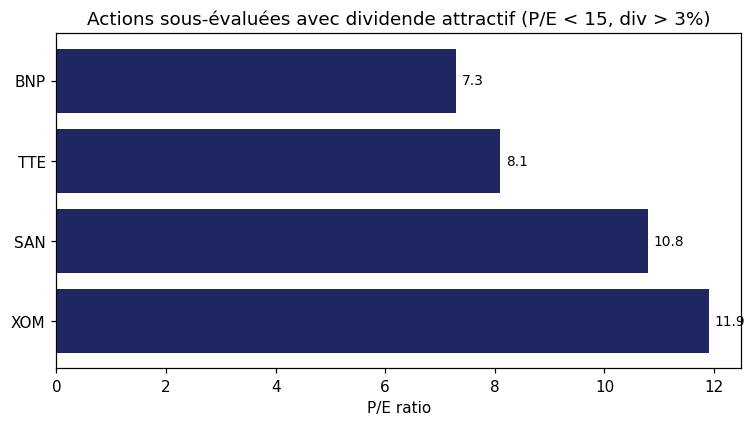

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(df_q2["ticker"], df_q2["pe_ratio"], color="#1E2761")
ax.invert_yaxis()
ax.set_title("Actions sous-evaluees avec dividende attractif (P/E < 15, div > 3%)")
ax.set_xlabel("P/E ratio")
for i, v in enumerate(df_q2["pe_ratio"]):
    ax.text(v + 0.1, i, f"{v}", va="center", fontsize=9)
fig.tight_layout()
plt.show()


**Lecture :** quatre actions ressortent du filtre — BNP Paribas, TotalEnergies, Sanofi et Exxon Mobil. Sans surprise, ce sont des secteurs matures (finance, énergie, santé) plutôt que la tech, structurellement plus chère en P/E.

## 3. Variation quotidienne d'une action (fonction `LAG`)

Exemple sur Apple : la fonction `LAG` permet de comparer chaque cours de clôture à celui de la veille sans auto-jointure.

In [5]:
Q3 = """
SELECT ticker, date_cours, cours_cloture,
    LAG(cours_cloture) OVER (PARTITION BY ticker ORDER BY date_cours) AS cours_veille,
    ROUND((cours_cloture - LAG(cours_cloture) OVER (PARTITION BY ticker ORDER BY date_cours))
        / LAG(cours_cloture) OVER (PARTITION BY ticker ORDER BY date_cours) * 100, 2) AS variation_pct
FROM cours WHERE ticker = 'AAPL' ORDER BY date_cours;
"""

df_q3 = pd.read_sql_query(Q3, conn)
df_q3.tail()

ticker,date_cours,cours_cloture,cours_veille,variation_pct
AAPL,2025-06-16,160.38,158.00,1.51
AAPL,2025-06-17,160.71,160.38,0.21
AAPL,2025-06-18,159.95,160.71,-0.47
AAPL,2025-06-19,160.30,159.95,0.22
AAPL,2025-06-20,154.77,160.30,-3.45


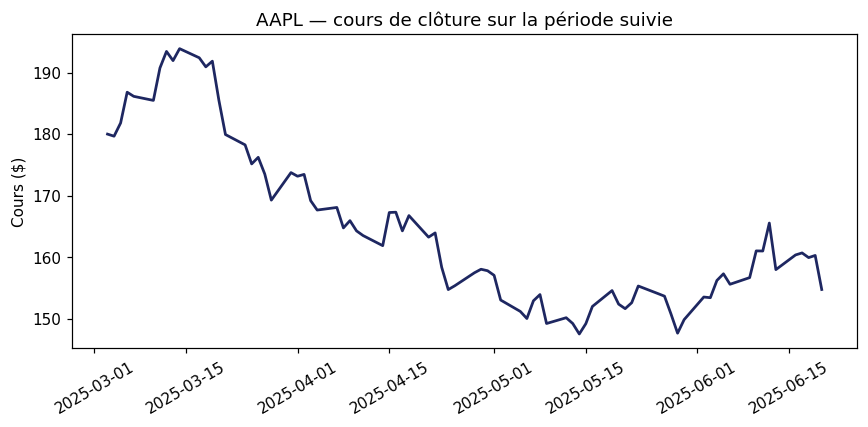

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pd.to_datetime(df_q3["date_cours"]), df_q3["cours_cloture"], color="#1E2761", linewidth=1.8)
ax.set_title("AAPL - cours de cloture sur la periode suivie")
ax.set_ylabel("Cours ($)")
plt.xticks(rotation=30)
fig.tight_layout()
plt.show()


## 4. Performance sectorielle moyenne (30 jours)

Une auto-jointure sur `cours` (date vs date - 30 jours) permet de comparer chaque secteur sans table de rendements pré-calculée.

In [7]:
Q4 = """
WITH perf_secteur AS (
    SELECT e.secteur, AVG((c.cours_cloture - c2.cours_cloture) / c2.cours_cloture) AS rendement_moyen
    FROM cours c
    JOIN cours c2 ON c.ticker = c2.ticker AND c2.date_cours = DATE(c.date_cours, '-30 days')
    JOIN entreprises e ON e.ticker = c.ticker
    GROUP BY e.secteur
)
SELECT secteur, ROUND(rendement_moyen * 100, 2) AS rendement_pct
FROM perf_secteur ORDER BY rendement_moyen DESC;
"""

df_q4 = pd.read_sql_query(Q4, conn)
df_q4

secteur,rendement_pct
Consommation,4.20
Finance,3.71
Sante,0.11
Energie,0.03
Technologie,-1.42


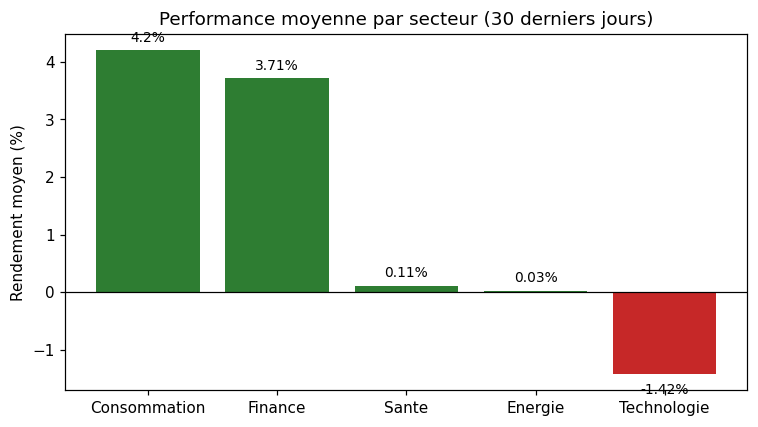

In [8]:
colors = ["#2E7D32" if v >= 0 else "#C62828" for v in df_q4["rendement_pct"]]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_q4["secteur"], df_q4["rendement_pct"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Performance moyenne par secteur (30 derniers jours)")
ax.set_ylabel("Rendement moyen (%)")
for i, v in enumerate(df_q4["rendement_pct"]):
    ax.text(i, v + (0.15 if v >= 0 else -0.35), f"{v}%", ha="center", fontsize=9)
fig.tight_layout()
plt.show()


## Limites et prochaines étapes

- Les données de ce notebook sont **simulées** ; en production, `entreprises`, `cours` et `indicateurs_financiers` seraient alimentées par un script d'extraction (`extract_data.py`, `yfinance`/Alpha Vantage) exécuté quotidiennement.
- Le screener utilise deux critères simples (P/E, dividende) ; une version plus poussée croiserait aussi la dette, la croissance du chiffre d'affaires et le secteur (comparaison intra-sectorielle plutôt qu'absolue).
- La performance sectorielle sur 30 jours est sensible aux points de départ/arrivée choisis ; à interpréter comme une tendance récente, pas une performance annualisée.
- Ce notebook ne constitue pas un conseil en investissement réglementé.


In [9]:
conn.close()